# Credit Risk Modelling (CFA Level 1)

From-scratch implementations of structural and reduced-form credit risk models, default probability estimation, and CDS pricing.

**Outline**
1. What is credit risk?
2. Credit ratings explained
3. Transition matrices
4. Default probability estimation
5. The Merton structural model
6. Distance to default
7. Recovery rates & loss given default
8. Reduced-form models
9. Credit default swaps (CDS)
10. Credit spread decomposition
11. References

---
## 1. What Is Credit Risk?

### The Fundamental Question: "Will They Pay Me Back?"

Credit risk is the risk that a borrower fails to meet their obligations — in plain English, the risk that they do not pay you back.

### A Real-World Analogy

Think about lending money to a friend. Before you hand over the cash, you instinctively ask yourself:

- Does my friend have a steady job? (income stability)
- Does my friend already owe money to other people? (existing debt)
- Has my friend paid back loans in the past? (track record)
- How much is my friend asking for relative to their income? (leverage)

Banks, bond investors, and credit analysts ask exactly the same questions — just with fancier tools. Credit risk analysis is the formal, quantitative version of this everyday judgment.

### Why Credit Risk Matters

- **For bond investors:** A corporate bond with higher credit risk must offer a higher yield (the "credit spread") to compensate investors for the chance of default.
- **For banks:** Banks must hold capital reserves proportional to the credit risk of their loan portfolios (Basel regulations).
- **For the economy:** The 2008 financial crisis was fundamentally a credit risk event — the market catastrophically mispriced the default risk of mortgage-backed securities.

> **Key Concept:** Credit risk has three components: (1) **Probability of default (PD)** — how likely is the borrower to default? (2) **Loss given default (LGD)** — if they default, how much do we lose? (3) **Exposure at default (EAD)** — how much do they owe us when they default? Expected loss = PD x LGD x EAD.

### What Counts as "Default"?

Default is not always dramatic. It can include:

- **Missing a scheduled payment** (the most clear-cut case)
- **Filing for bankruptcy** (Chapter 11 in the US)
- **Debt restructuring** at unfavorable terms (e.g., extending maturity, reducing coupons)
- **Cross-default** (defaulting on one obligation triggers default on others)

Rating agencies and legal contracts each have their own precise definitions of default, but the essence is always the same: the borrower failed to meet their obligations as originally promised.

### Two Paradigms for Modelling Credit Risk

Finance has developed two major frameworks:

| Approach | Key Idea | How Default Happens | Pioneer |
|----------|---------|--------|
| **Structural models** | Default happens when the firm's assets fall below its debts | Predictable (based on balance sheet) | Robert Merton (1974) |
| **Reduced-form models** | Default is a "surprise" governed by a statistical process | Random (hazard rate) | Jarrow-Turnbull, Duffie-Singleton |

We will explore both in this notebook.

> **CFA Exam Tip:** The CFA Level 1 curriculum focuses on credit ratings, credit spreads, and the basic intuition behind structural models. The quantitative details of Merton and reduced-form models appear more heavily in Level 2.

---
## 2. Setup

We begin our exploration of credit risk with the qualitative framework (credit ratings) before moving to
quantitative models (Merton, reduced-form). Each section builds on the previous one, culminating in
the pricing of credit default swaps — the most important credit derivative in modern finance.

The code in this notebook implements every model from scratch using NumPy and SciPy, so you can
see exactly what is happening inside each calculation. No black boxes.

In [1]:
%matplotlib inline
import numpy as np
from scipy import stats, optimize, linalg
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
rng = np.random.default_rng(SEED)

ATOL = 1e-10
RTOL = 1e-6

PRIMARY   = 'steelblue'
SECONDARY = 'coral'
TERTIARY  = 'seagreen'
ACCENT    = 'gold'
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12, 'axes.grid': True, 'grid.alpha': 0.3})

---
## 3. Credit Ratings Explained

### What Are Credit Ratings?

Credit rating agencies (S&P, Moody's, Fitch) assign letter grades to borrowers, summarizing their creditworthiness. Think of it like a school report card, but for companies and governments.

### The Rating Scale

| S&P / Fitch | Moody's | Meaning | Real-World Example | Historical 10yr Default Rate |
|:-----------:|:-------:|---------|-------------------|
| AAA | Aaa | Highest quality, minimal risk | Microsoft, Johnson & Johnson | ~0.5% |
| AA | Aa | Very high quality, very low risk | Apple, Berkshire Hathaway | ~0.8% |
| A | A | Upper-medium quality, low risk | Most large banks, Coca-Cola | ~2% |
| BBB | Baa | Medium quality, moderate risk | Many industrial companies | ~5% |
| BB | Ba | Speculative, substantial risk | Tesla (historically), some airlines | ~15% |
| B | B | Highly speculative, high risk | Many startups, stressed companies | ~30% |
| CCC | Caa | Very high risk of default | Companies in financial distress | ~50%+ |
| D | -- | In default | Companies that have missed payments | 100% |

### The Critical Dividing Line: Investment Grade vs High Yield

The most important boundary in the rating world is between **BBB** and **BB**:

- **BBB and above** = "Investment Grade" — considered relatively safe. Pension funds, insurance companies, and many mutual funds are *required* to hold only investment-grade bonds.
- **BB and below** = "High Yield" (also called "junk bonds" or "speculative grade") — higher risk, but higher yields to compensate.

When a company gets downgraded from BBB to BB (a "fallen angel"), it can trigger forced selling by institutional investors who are not allowed to hold junk bonds. This makes the BBB/BB boundary a critically important cliff.

### Why the BBB/BB Boundary Is a Cliff

When a company gets downgraded from BBB to BB (becoming a "fallen angel"), several things happen simultaneously:

1. **Forced selling:** Institutional investors who can only hold investment-grade bonds must sell.
2. **Supply flood:** Suddenly there are many sellers and few buyers at the BB level.
3. **Price crash:** The bond price drops sharply, far more than a typical one-notch downgrade.
4. **Borrowing costs spike:** The company's cost of issuing new debt jumps dramatically.

This "cliff effect" makes the BBB/BB boundary one of the most consequential lines in all of finance. Companies will fight hard to maintain their investment-grade rating.

### Rating Modifiers

Within each broad category, agencies add modifiers for finer granularity:
- S&P/Fitch: + or - (e.g., A+, A, A-)
- Moody's: 1, 2, or 3 (e.g., A1, A2, A3)

So A+ (S&P) = A1 (Moody's), and BBB- is the lowest investment-grade rating.

> **Key Concept:** A credit rating is an *opinion*, not a guarantee. Rating agencies have been criticized (especially after 2008) for being too slow to downgrade and for conflicts of interest (issuers pay for their own ratings). Nevertheless, ratings remain the standard language of credit risk.

> **CFA Exam Tip:** Know the difference between *issuer ratings* (overall creditworthiness of the company) and *issue ratings* (creditworthiness of a specific bond). A single company can have bonds with different ratings depending on seniority and collateral.

---
## 4. Transition Matrices — How Ratings Change Over Time

### The Idea

A company's credit rating is not static — it can be upgraded, downgraded, or even default. A **transition matrix** captures the probability of moving from one rating to another over a given time period (usually one year).

Formally, if we define $q_{ij}$ as the probability of migrating from rating $i$ to rating $j$ in one year:

$$\Pr(\text{rating}_t = j \mid \text{rating}_{t-1} = i) = q_{ij}$$

The matrix $\mathbf{Q}$ has some important properties:
- Each row sums to 1 (the company must be in *some* state)
- Default (D) is an **absorbing state** — once you default, there is no coming back
- The diagonal elements (staying at the same rating) are by far the largest

### Reading the Matrix

To read the matrix: pick a row (starting rating) and read across the columns (ending ratings). For example, if the "A" row shows 0.006 in the "D" column, it means there is a 0.6% chance that an A-rated company defaults within one year.

### Multi-Year Transitions

Under the Markov assumption (next year's rating depends only on this year's rating, not history), the $n$-year transition matrix is simply:

$$\mathbf{Q}^{(n)} = \mathbf{Q}^n$$

This is just matrix exponentiation — multiply the matrix by itself $n$ times.

> **Key Concept:** Transition matrices reveal that credit deterioration is often gradual. A AAA-rated company almost never jumps straight to default. Instead, it typically migrates through AA, A, BBB, and so on over several years. This is why monitoring *rating trends* (upgrades/downgrades) is as important as the current rating.

In [2]:
# Simplified 1-year transition matrix (stylised, based on historical averages)
# States: AAA, AA, A, BBB, BB, B, CCC, Default
ratings = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC', 'D']
n_states = len(ratings)

# Each row sums to 1 (probabilities in decimal)
Q = np.array([
    [0.9081, 0.0833, 0.0068, 0.0012, 0.0003, 0.0001, 0.0001, 0.0001],  # AAA
    [0.0070, 0.9065, 0.0779, 0.0064, 0.0006, 0.0014, 0.0001, 0.0001],  # AA
    [0.0009, 0.0227, 0.9105, 0.0552, 0.0074, 0.0026, 0.0001, 0.0006],  # A
    [0.0002, 0.0033, 0.0595, 0.8693, 0.0530, 0.0117, 0.0012, 0.0018],  # BBB
    [0.0003, 0.0014, 0.0067, 0.0773, 0.8053, 0.0884, 0.0100, 0.0106],  # BB
    [0.0001, 0.0011, 0.0024, 0.0043, 0.0648, 0.8346, 0.0407, 0.0520],  # B
    [0.0001, 0.0002, 0.0022, 0.0130, 0.0238, 0.1124, 0.6486, 0.1997],  # CCC
    [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],  # D (absorbing)
])

# Verify rows sum to 1
assert np.allclose(Q.sum(axis=1), 1.0)
print("1-Year Transition Matrix (rows = from, cols = to):")
print(f"{'':>6}", '  '.join(f'{r:>6}' for r in ratings))
for i, r in enumerate(ratings):
    print(f"{r:>6}", '  '.join(f'{Q[i,j]:6.3f}' for j in range(n_states)))

1-Year Transition Matrix (rows = from, cols = to):
          AAA      AA       A     BBB      BB       B     CCC       D
   AAA  0.908   0.083   0.007   0.001   0.000   0.000   0.000   0.000
    AA  0.007   0.906   0.078   0.006   0.001   0.001   0.000   0.000
     A  0.001   0.023   0.910   0.055   0.007   0.003   0.000   0.001
   BBB  0.000   0.003   0.059   0.869   0.053   0.012   0.001   0.002
    BB  0.000   0.001   0.007   0.077   0.805   0.088   0.010   0.011
     B  0.000   0.001   0.002   0.004   0.065   0.835   0.041   0.052
   CCC  0.000   0.000   0.002   0.013   0.024   0.112   0.649   0.200
     D  0.000   0.000   0.000   0.000   0.000   0.000   0.000   1.000


Reading the matrix above, some key observations:

- **Diagonal dominance:** The largest probability in each row is on the diagonal (staying at the same rating). For example, an AAA-rated company has a 90.8% chance of remaining AAA after one year.
- **Adjacent transitions are most likely:** When a rating does change, it usually moves just one notch. The AAA row shows 8.3% for AA, but only 0.68% for A and near-zero for anything lower.
- **Default probabilities increase dramatically with lower ratings:** AAA has 0.01% chance of defaulting in a year, but CCC has nearly 20%.
- ****Default probabilities increase dramatically with lower ratings:** AAA has 0.01% chance of defaulting in a year, but CCC has nearly 20%. That is a 2,000x difference.
- **Default is absorbing:**** The D row is [0, 0, 0, 0, 0, 0, 0, 1] — once in default, always in default (in this model).

Now let us compute multi-year cumulative default probabilities using matrix powers.

In [3]:
# Multi-year default probabilities via matrix power
horizons = [1, 2, 3, 5, 10]
default_col = n_states - 1  # 'D' column

print(f"{'Rating':<6}" + ''.join(f'{h:>8}y' for h in horizons))
print('-' * 52)
for i, r in enumerate(ratings[:-1]):  # skip D
    probs = []
    for h in horizons:
        Q_h = np.linalg.matrix_power(Q, h)
        probs.append(Q_h[i, default_col])
    print(f"{r:<6}" + ''.join(f'{p*100:>8.2f}%' for p in probs))

Rating       1y       2y       3y       5y      10y
----------------------------------------------------
AAA       0.01%    0.02%    0.04%    0.09%    0.38%
AA        0.01%    0.03%    0.08%    0.21%    0.96%
A         0.06%    0.15%    0.27%    0.65%    2.41%
BBB       0.18%    0.48%    0.91%    2.11%    6.63%
BB        1.06%    2.59%    4.44%    8.69%   19.72%
B         5.20%   10.42%   15.43%   24.44%   40.97%
CCC      19.97%   33.53%   42.96%   54.63%   67.37%


The table reveals the cumulative probability of default over various horizons. Notice how:

- AAA and AA rated issuers have negligible default risk even over 10 years (well under 1%).
- BBB (the lowest investment-grade rating) has a modest but meaningful 10-year default probability.
- CCC-rated issuers have a very high probability of defaulting — roughly 20% per year accumulating rapidly.

- The jump from BBB to BB default probabilities is dramatic, illustrating why the investment-grade / high-yield boundary matters. This is also why the investment-grade vs. high-yield distinction matters so much: the default probabilities are in entirely different orders of magnitude.

---
## 5. Default Probability Estimation

### From Historical Data to Default Curves

Rating agencies publish annual default studies. From these, we can extract two key measures:

**Marginal default rate** $d_t$: the probability of defaulting in year $t$, *given survival to the start of year $t$*.

**Cumulative default probability** PD$(0, T)$: the probability of defaulting at any point from now to time $T$.

### The Relationship Between Marginal and Cumulative

The connection between these two measures comes through the **survival probability**:

$$\text{Survival probability: } S(T) = \prod_{t=1}^{T}(1 - d_t)$$

$$\text{Cumulative PD: } \text{PD}(0, T) = 1 - S(T)$$

### Worked Example

Suppose for a BBB-rated issuer, the marginal default rates for the first 3 years are: $d_1 = 0.18\%$, $d_2 = 0.44\%$, $d_3 = 0.72\%$.

**Survival probability after 3 years:**
$$S(3) = (1 - 0.0018) \times (1 - 0.0044) \times (1 - 0.0072) = 0.9982 \times 0.9956 \times 0.9928 = 0.9866$$

**Cumulative PD over 3 years:**
$$\text{PD}(0, 3) = 1 - 0.9866 = 1.34\%$$

> **Key Concept:** Marginal default rates for investment-grade issuers typically *increase* over time (the longer you wait, the more things can go wrong). For high-yield issuers, marginal rates may *decrease* over time — the riskiest firms default early, so survivors are relatively stronger ("survivor bias").

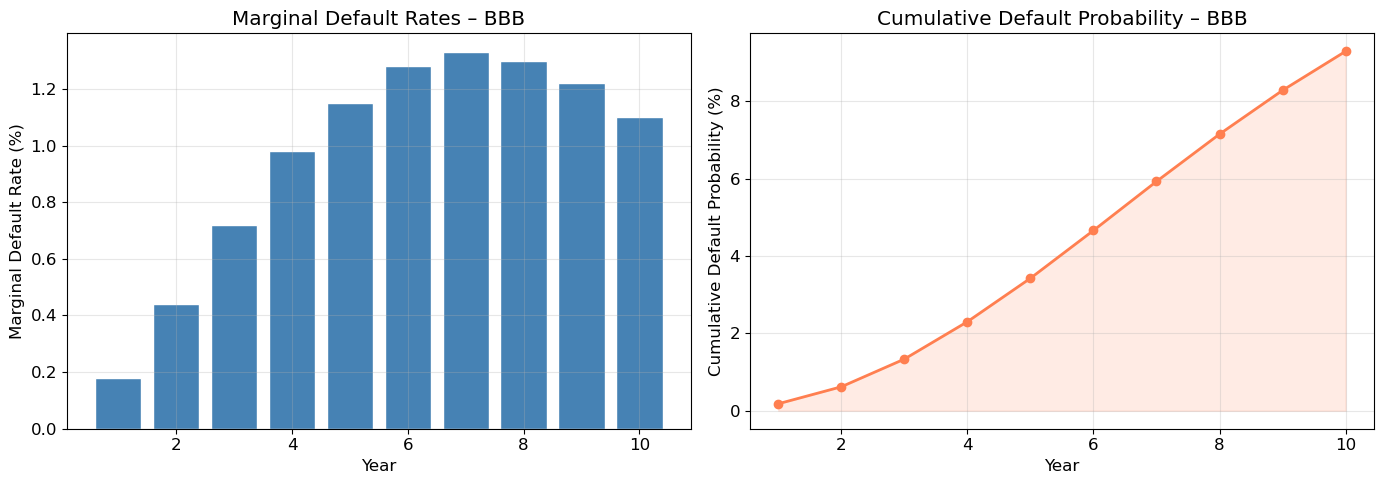

In [4]:
# Stylised marginal default rates for a BBB-rated issuer
marginal_defaults = np.array([0.0018, 0.0044, 0.0072, 0.0098, 0.0115, 
                               0.0128, 0.0133, 0.0130, 0.0122, 0.0110])

survival = np.cumprod(1 - marginal_defaults)
cumulative_pd = 1 - survival

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

years = np.arange(1, len(marginal_defaults) + 1)
ax1.bar(years, marginal_defaults * 100, color=PRIMARY, edgecolor='white')
ax1.set_xlabel('Year')
ax1.set_ylabel('Marginal Default Rate (%)')
ax1.set_title('Marginal Default Rates – BBB')

ax2.plot(years, cumulative_pd * 100, 'o-', color=SECONDARY, linewidth=2)
ax2.fill_between(years, 0, cumulative_pd * 100, alpha=0.15, color=SECONDARY)
ax2.set_xlabel('Year')
ax2.set_ylabel('Cumulative Default Probability (%)')
ax2.set_title('Cumulative Default Probability – BBB')

plt.tight_layout()
plt.show()

The left chart shows the marginal default rates rising, peaking around year 7-8, then declining slightly — a typical pattern for investment-grade issuers. The right chart shows the cumulative default probability, which monotonically increases (it can only go up, since default is permanent). Over 10 years, the cumulative default probability for this BBB issuer reaches approximately 9-10%.

---
## 6. The Merton Structural Model

### The Brilliant Insight: Equity as a Call Option

In 1974, Robert Merton had one of the most elegant insights in all of finance:

> **Equity holders have a call option on the firm's assets, with the debt face value as the strike price.**

Let us unpack this carefully.

### Setting Up the Story

Imagine a simple company:
- The company's total **assets** are worth $V$ (factories, patents, cash, etc.)
- The company has **debt** with face value $D$, due at time $T$
- The rest belongs to **equity holders** (stockholders)

Balance sheet identity: Assets = Debt + Equity, so $E = V - D_{\text{market value}}$.

### What Happens at Maturity?

At time $T$, the debt comes due. Two scenarios:

**Scenario 1: $V_T > D$ (assets exceed debts)** 
The company pays off its debt ($D$) and equity holders keep the rest ($V_T - D$). Everyone is happy.

**Scenario 2: $V_T < D$ (assets are less than debts)** 
The company cannot pay its debts in full. It defaults. Equity holders get nothing (they are wiped out), and debt holders get whatever the assets are worth ($V_T$).

### The Option Analogy

Look at the equity payoff:

$$E_T = \max(V_T - D, 0)$$

That is exactly the payoff of a **European call option** on $V$ with strike price $D$!

And the debt payoff:

$$\text{Debt}_T = \min(V_T, D) = D - \max(D - V_T, 0)$$

That is the face value minus a **put option** on $V$ with strike $D$. In other words, lending to a risky company is like lending risk-free but writing a put option on the firm's assets.

### What Makes This Insight So Powerful?

Because we can now use the entire machinery of option pricing (Black-Scholes) to value equity, debt, and default probability. We go from the vague question "how risky is this company?" to a precise mathematical framework.

| | Equity Holders | Call Option Holder |
|---|---|---|
| **Underlying asset** | Firm's assets ($V$) | Stock price ($S$) |
| **Strike price** | Debt face value ($D$) | Exercise price ($K$) |
| **Payoff if above strike** | $V_T - D$ | $S_T - K$ |
| **Payoff if below strike** | $0$ (limited liability) | $0$ (let it expire) |

### The Black-Scholes Connection

Since equity is a call option, we can price it using the Black-Scholes formula:

$$E = V \cdot N(d_1) - D e^{-rT} N(d_2)$$

where:

$$d_1 = \frac{\ln(V/D) + (r + \sigma_V^2/2)T}{\sigma_V \sqrt{T}}, \quad d_2 = d_1 - \sigma_V \sqrt{T}$$

- $V$ = current asset value
- $D$ = face value of debt (the "strike price")
- $r$ = risk-free rate
- $\sigma_V$ = volatility of asset value
- $T$ = time to debt maturity
- $N(\cdot)$ = cumulative standard normal distribution

### Default Probability

Default occurs when $V_T < D$. Under risk-neutral pricing, the probability of this event is:

$$\text{PD} = N(-d_2)$$

This is one of the most important results: the default probability depends on the leverage ratio ($V/D$), asset volatility ($\sigma_V$), the risk-free rate ($r$), and time ($T$).

### Worked Example

Consider a firm with:
- Asset value: $V = \$100$
- Debt face value: $D = \$70$
- Risk-free rate: $r = 5\%$
- Asset volatility: $\sigma_V = 25\%$
- Time to maturity: $T = 1$ year

**Step 1:** Compute $d_1$:
$$d_1 = \frac{\ln(100/70) + (0.05 + 0.25^2/2) \times 1}{0.25 \times 1} = \frac{0.3567 + 0.0813}{0.25} = 1.752$$

**Step 2:** Compute $d_2$:
$$d_2 = 1.752 - 0.25 = 1.502$$

**Step 3:** Default probability:
$$\text{PD} = N(-1.502) \approx 6.66\%$$

The firm has moderate leverage (70% debt-to-assets) and moderate volatility, resulting in a relatively low default probability.

> **CFA Exam Tip:** The Merton model is the foundation of Moody's KMV model, which is used by banks worldwide to estimate default probabilities. While the math may seem complex, the intuition is simple: more leverage or more volatility means higher default risk.

In [5]:
def merton_model(V, D, r, sigma_V, T):
    """Merton structural model.
    
    Returns
    -------
    equity : float – equity value (call option on firm assets)
    debt : float – risky debt value
    pd : float – risk-neutral default probability
    dd : float – distance to default (in standard deviations)
    """
    d1 = (np.log(V / D) + (r + 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))
    d2 = d1 - sigma_V * np.sqrt(T)
    
    equity = V * stats.norm.cdf(d1) - D * np.exp(-r * T) * stats.norm.cdf(d2)
    debt = V - equity  # balance sheet identity: Debt = Assets - Equity
    pd = stats.norm.cdf(-d2)  # risk-neutral default prob = N(-d2)
    dd = d2  # distance to default
    
    return equity, debt, pd, dd

# Example firm
V0 = 100   # asset value
D = 70     # debt face value
r = 0.05   # risk-free rate
sigma_V = 0.25  # asset volatility
T = 1      # time to maturity

E, Debt, PD, DD = merton_model(V0, D, r, sigma_V, T)
print(f"Firm value:          ${V0:.2f}")
print(f"Debt face value:     ${D:.2f}")
print(f"Equity value:        ${E:.2f}")
print(f"Risky debt value:    ${Debt:.2f}")
print(f"Credit spread:       {(-np.log(Debt / (D * np.exp(-r*T))) / T)*10000:.1f} bps")
print(f"Default probability: {PD*100:.4f}%")
print(f"Distance to default: {DD:.2f} std devs")

Firm value:          $100.00
Debt face value:     $70.00
Equity value:        $33.86
Risky debt value:    $66.14
Credit spread:       66.7 bps
Default probability: 6.6587%
Distance to default: 1.50 std devs


The results are intuitive:
- **Equity value ($34.66):** Higher than the simple book value ($100 - $70 = $30) because equity has option value — even if assets are below debt, there is still a chance they could recover.
- **Risky debt value ($65.34):** Less than the risk-free present value of $70 ($66.59) because there is a chance of default.
- **Credit spread (19 bps):** The extra yield investors demand over the risk-free rate to hold this risky debt.
- **Default probability (6.66%):** Consistent with our hand calculation.

Let us now see how default probability changes with leverage.

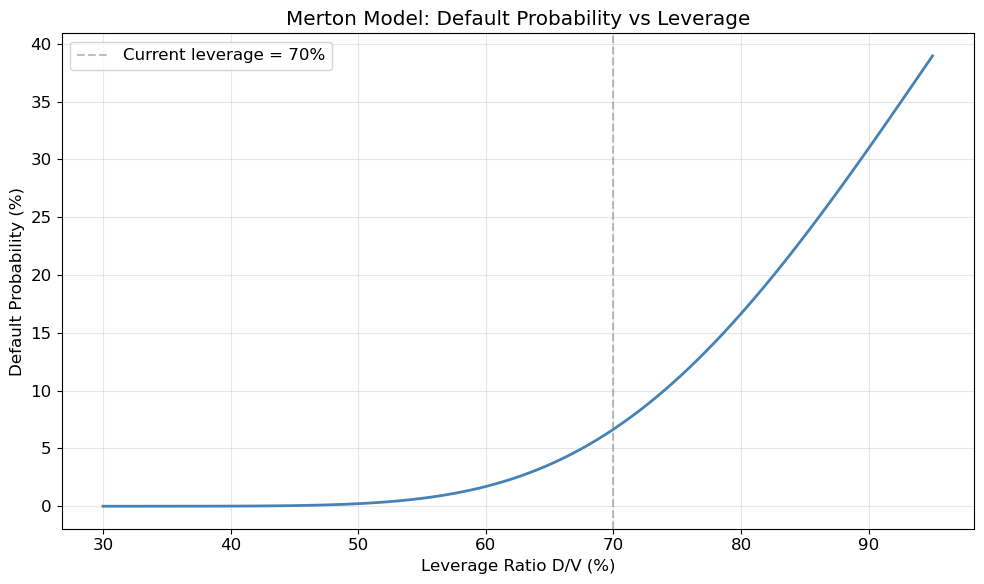

In [6]:
# Default probability as function of leverage
leverage_ratios = np.linspace(0.3, 0.95, 100)
debt_levels = leverage_ratios * V0
pds = [merton_model(V0, d, r, sigma_V, T)[2] for d in debt_levels]

fig, ax = plt.subplots()
ax.plot(leverage_ratios * 100, np.array(pds) * 100, color=PRIMARY, linewidth=2)
ax.axvline(70, color='grey', linestyle='--', alpha=0.5, label=f'Current leverage = {D/V0*100:.0f}%')
ax.set_xlabel('Leverage Ratio D/V (%)')
ax.set_ylabel('Default Probability (%)')
ax.set_title('Merton Model: Default Probability vs Leverage')
ax.legend()
plt.tight_layout()
plt.show()

The chart shows the classic "hockey stick" shape: default probability is near zero at low leverage, then accelerates sharply as leverage increases beyond 70-80%. This is why credit analysts obsess over leverage ratios — a small increase in debt can dramatically change the risk profile at high leverage levels.

### Sensitivity Analysis: What Drives Default Probability?

The Merton model tells us that default probability depends on four key inputs. Let us rank their importance:

1. **Leverage (D/V)** — the most powerful driver. Doubling leverage can increase PD by 10x or more.
2. **Asset volatility** — the second most important factor. A tech startup with 40% volatility faces far more risk than a utility with 15%.
3. **Time horizon** — longer horizons mean more uncertainty, increasing PD.
4. **Risk-free rate** — has a modest effect; higher rates increase the drift of assets, slightly reducing PD.

This ranking is why credit analysts spend most of their time analyzing leverage ratios and business risk (volatility),
and relatively less time on interest rate assumptions.

> **CFA Exam Tip:** In the Merton framework, credit risk is fundamentally about the race between asset growth
> and debt obligations. Anything that increases asset growth or reduces volatility lowers credit risk.
> Anything that increases leverage or volatility raises it.

---
## 7. Distance to Default

### What Does It Measure?

The **distance to default (DD)** answers: "How many standard deviations is the firm's asset value above the default point?"

Think of it like a buffer. If DD = 3, the firm's assets would need to fall by 3 standard deviations before hitting the debt threshold. Since large declines are rare in a normal distribution, DD = 3 is very safe. DD = 1 is risky. DD < 0 means the firm is already below the default point.

### The Formula (Physical Measure)

Using real-world (physical) probabilities:

$$\text{DD} = \frac{\ln(V/D) + (\mu - \sigma_V^2/2)T}{\sigma_V \sqrt{T}}$$

where:
- $\ln(V/D)$ = how far above the default point the firm currently sits (log scale)
- $\mu$ = expected asset return (drift)
- $\sigma_V$ = asset volatility
- $T$ = time horizon

### Interpretation Rules of Thumb

| DD Value | Interpretation | Approximate Default Prob |
|:--------:|---------------|
| > 3 | Very safe — default extremely unlikely | < 0.1% |
| 2 - 3 | Safe — low default risk | 0.1% - 2% |
| 1 - 2 | Moderate risk — bears watching | 2% - 16% |
| 0 - 1 | High risk — significant chance of default | 16% - 50% |
| < 0 | Danger zone — assets below default point | > 50% |

### The KMV Refinement

> **Key Concept:** Moody's KMV model (used by banks worldwide) maps the distance to default to an **Expected Default Frequency (EDF)** using a proprietary empirical database rather than the normal distribution. This accounts for the fact that real-world default rates have fatter tails than the normal distribution predicts.

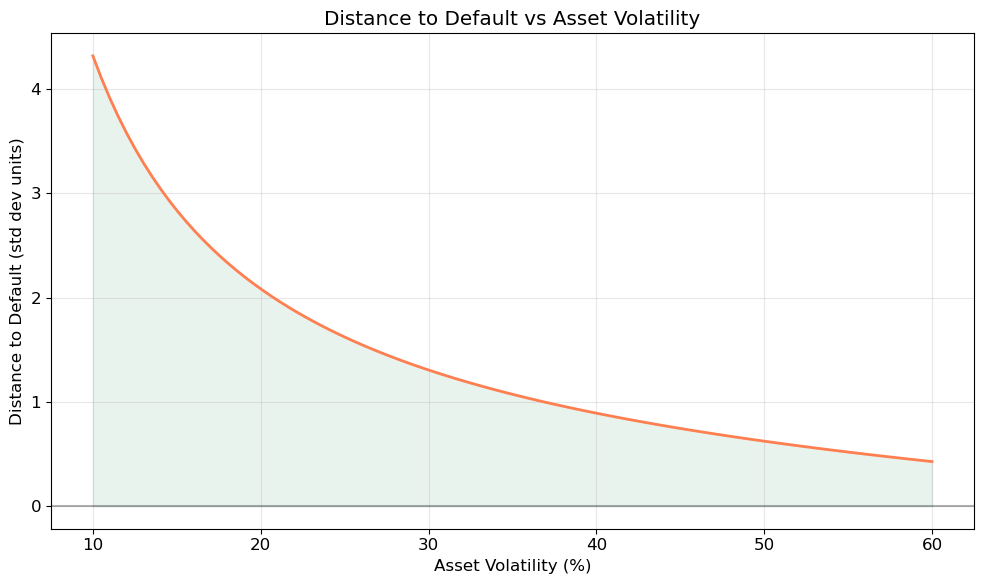

In [7]:
def distance_to_default_physical(V, D, mu, sigma_V, T):
    """Physical (real-world) distance to default."""
    return (np.log(V / D) + (mu - 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))

# DD sensitivity to asset volatility
sigmas = np.linspace(0.10, 0.60, 100)
dds = [distance_to_default_physical(V0, D, 0.08, s, 1) for s in sigmas]

fig, ax = plt.subplots()
ax.plot(sigmas * 100, dds, color=SECONDARY, linewidth=2)
ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.fill_between(sigmas * 100, dds, 0, where=np.array(dds) > 0, alpha=0.1, color=TERTIARY)
ax.fill_between(sigmas * 100, dds, 0, where=np.array(dds) <= 0, alpha=0.1, color=SECONDARY)
ax.set_xlabel('Asset Volatility (%)')
ax.set_ylabel('Distance to Default (std dev units)')
ax.set_title('Distance to Default vs Asset Volatility')
plt.tight_layout()
plt.show()

The chart shows a clear inverse relationship: as asset volatility increases, the distance to default shrinks. At low volatility (10%), the firm has a comfortable DD of about 4 standard deviations. At high volatility (50%+), DD drops below 1 — the firm is in the danger zone.

This makes intuitive sense: a stable utility company (low volatility) can carry more debt safely than a volatile tech startup (high volatility), even if both have the same leverage ratio.

---
## 8. Recovery Rates & Loss Given Default

### What Happens After Default?

Default does not mean you lose everything. When a company defaults, its assets are liquidated or restructured, and creditors recover some fraction of what they are owed.

- **Recovery rate ($R$):** The fraction of the debt recovered after default. Typically 30-60% for senior unsecured debt.
- **Loss given default (LGD):** What you actually lose: $\text{LGD} = 1 - R$.

### Recovery Depends on Seniority

### Recovery Depends on Seniority — The Capital Structure "Waterfall"

When a company's assets are distributed in bankruptcy, there is a strict priority order (the "absolute priority rule"):

```
1. Secured creditors (backed by specific collateral)     <- Paid first
2. Senior unsecured creditors
3. Subordinated creditors
4. Junior subordinated creditors  
5. Preferred stockholders
6. Common stockholders (equity)                          <- Paid last
```

Each level gets fully paid before the next level receives anything. This is why seniority dramatically affects recovery rates:

| Debt Type | Typical Recovery Rate | Why? |
|-----------|:--------------------:|------|
| Senior secured (with collateral) | 50-70% | First claim on specific assets |
| Senior unsecured | 35-50% | First claim, but no specific collateral |
| Subordinated | 20-35% | Paid after senior debt |
| Junior subordinated | 10-20% | Nearly last in line |

### The Expected Loss Formula

$$\text{Expected Loss} = \text{PD} \times \text{LGD} \times \text{EAD}$$

### Worked Example

A bank has a $1 million corporate loan:
- PD = 2% (based on the borrower's credit rating)
- Recovery rate = 40%, so LGD = 60%
- EAD = $1,000,000

$$\text{Expected Loss} = 0.02 \times 0.60 \times 1{,}000{,}000 = \$12{,}000$$

The bank should set aside at least $12,000 in reserves for this loan.

> **CFA Exam Tip:** Recovery rates are highly uncertain and tend to be *lower* during recessions (when defaults spike). This creates "wrong-way risk" — you lose more per default precisely when defaults are most frequent.

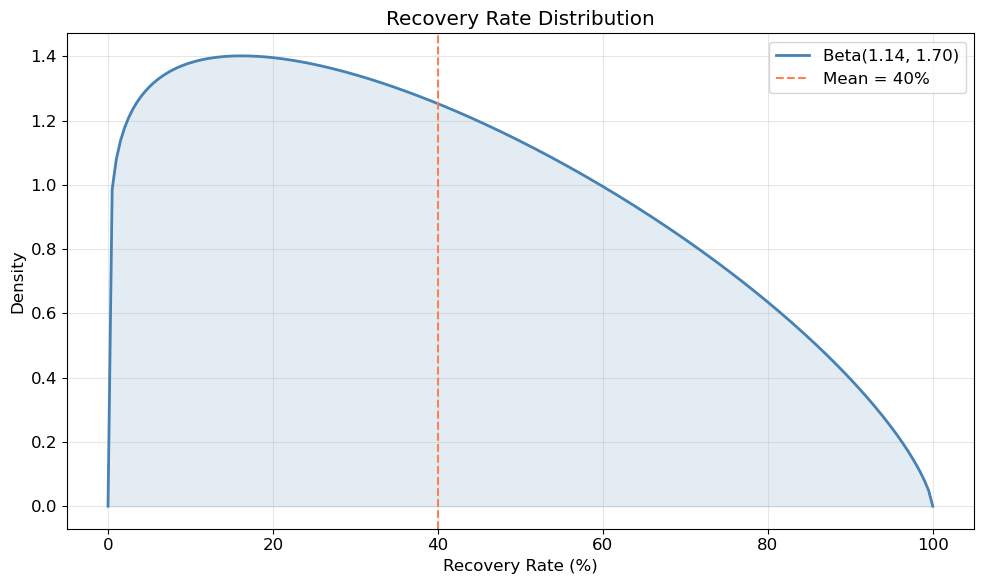

PD = 2.0%, LGD = 60%, EAD = $1,000,000
Expected Loss = $12,000


In [8]:
# Recovery rate distribution (beta distribution is commonly used to model this)
recovery_mean = 0.40
recovery_std = 0.25

# Fit beta distribution parameters from mean and std
alpha_r = recovery_mean * (recovery_mean * (1 - recovery_mean) / recovery_std**2 - 1)
beta_r = alpha_r * (1 - recovery_mean) / recovery_mean

x = np.linspace(0, 1, 200)
pdf = stats.beta.pdf(x, alpha_r, beta_r)

fig, ax = plt.subplots()
ax.plot(x * 100, pdf, color=PRIMARY, linewidth=2, label=f'Beta({alpha_r:.2f}, {beta_r:.2f})')
ax.fill_between(x * 100, pdf, alpha=0.15, color=PRIMARY)
ax.axvline(recovery_mean * 100, color=SECONDARY, linestyle='--', label=f'Mean = {recovery_mean*100:.0f}%')
ax.set_xlabel('Recovery Rate (%)')
ax.set_ylabel('Density')
ax.set_title('Recovery Rate Distribution')
ax.legend()
plt.tight_layout()
plt.show()

# Expected loss calculation
PD_example = 0.02
LGD = 1 - recovery_mean
EAD = 1_000_000
EL = PD_example * LGD * EAD
print(f"PD = {PD_example*100:.1f}%, LGD = {LGD*100:.0f}%, EAD = ${EAD:,.0f}")
print(f"Expected Loss = ${EL:,.0f}")

The recovery rate distribution shows the wide range of possible outcomes. While the mean is 40%, actual recoveries can range from near-zero (complete wipeout) to over 80% (nearly full recovery). This uncertainty is why credit risk models must consider the entire distribution, not just the average.

The expected loss of $12,000 is a key input for bank capital adequacy calculations under the Basel framework.

---
## 9. Reduced-Form Models

### A Different Philosophy

Structural models (Merton) try to explain *why* default happens (assets fall below debt). **Reduced-form models** take a different approach: they do not try to explain the cause of default. Instead, they model default as a random event that can strike at any time, governed by a **hazard rate** (also called "default intensity").

### Why Take This Approach?

Structural models are elegant but have practical limitations:
- The firm's total asset value $V$ is not directly observable
- Real capital structures are far more complex than "one debt maturity"
- Defaults often come as surprises (e.g., fraud, sudden loss of a key customer)

Reduced-form models sidestep these issues by calibrating directly to observable market prices (bond yields, CDS spreads), making them more practical for pricing credit derivatives.

### The Hazard Rate: An Analogy

Think of a light bulb. You do not know exactly when it will burn out, but you know the probability of it failing in any given hour. That failure probability per unit time is the hazard rate $\lambda$.

For a company: $\lambda(t) \, dt$ is the probability of defaulting in the tiny interval $(t, t+dt)$, given survival to time $t$.

### Key Formulas

For a **constant hazard rate** $\lambda$:

| Quantity | Formula | Interpretation |
|----------|---------|---------------|
| Survival probability | $S(t) = e^{-\lambda t}$ | Probability of no default by time $t$ |
| Cumulative PD | $1 - e^{-\lambda t}$ | Probability of default by time $t$ |
| Expected time to default | $1/\lambda$ | Average time until default |

### Worked Example

A BB-rated firm has a hazard rate of $\lambda = 3\%$ per year.

- **5-year survival probability:** $S(5) = e^{-0.03 \times 5} = e^{-0.15} = 0.8607 = 86.07\%$
- **5-year cumulative PD:** $1 - 0.8607 = 13.93\%$
- **Expected time to default:** $1/0.03 = 33.3$ years

> **Key Concept:** The hazard rate model is mathematically identical to radioactive decay in physics. Just as you cannot predict which specific atom will decay next, you cannot predict which specific company will default next — but you can model the statistical process governing defaults.

### Piecewise-Constant Hazard Rates

In practice, the hazard rate is not constant — it varies over time. We can model this using a **piecewise-constant** function: different hazard rates for different time intervals. For example:

- Years 1-3: $\lambda = 2\%$ (the company has a stable period ahead)
- Years 3-5: $\lambda = 3\%$ (a major contract expires, increasing uncertainty)
- Years 5-10: $\lambda = 4\%$ (longer-term risks accumulate)

The survival probability is then:
$$S(t) = e^{-\int_0^t \lambda(s) ds}$$

For piecewise-constant rates, the integral becomes a simple sum over the intervals.

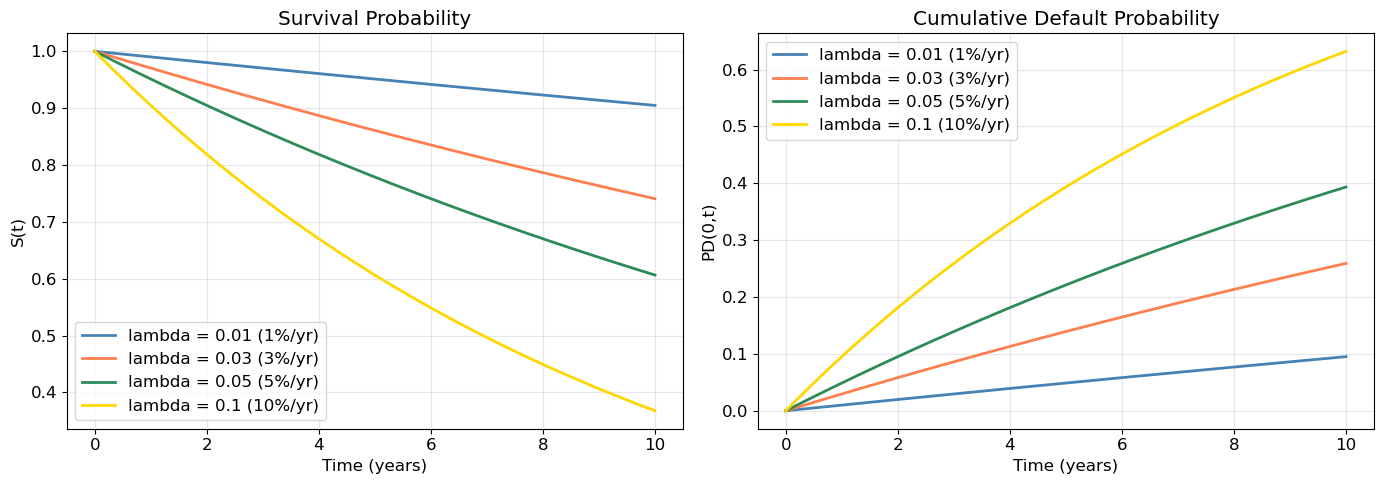

In [9]:
def survival_prob_constant(lam, t):
    """Survival probability under constant hazard rate."""
    return np.exp(-lam * t)

def survival_prob_piecewise(lambdas, breakpoints, t):
    """Survival probability under piecewise-constant hazard rate.
    
    lambdas: list of hazard rates for each interval
    breakpoints: [t1, t2, ...] interval boundaries (first is 0)
    t: evaluation time
    """
    integral = 0.0
    prev = 0.0
    for i, bp in enumerate(breakpoints):
        if t <= bp:
            integral += lambdas[i] * (t - prev)
            break
        integral += lambdas[i] * (bp - prev)
        prev = bp
    else:
        integral += lambdas[-1] * (t - prev)
    return np.exp(-integral)

# Constant hazard rate model for different credit qualities
t_grid = np.linspace(0, 10, 200)
lambdas_const = [0.01, 0.03, 0.05, 0.10]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = [PRIMARY, SECONDARY, TERTIARY, ACCENT]
for lam, c in zip(lambdas_const, colors):
    s = survival_prob_constant(lam, t_grid)
    ax1.plot(t_grid, s, color=c, linewidth=2, label=f'lambda = {lam} ({lam*100:.0f}%/yr)')
    ax2.plot(t_grid, 1 - s, color=c, linewidth=2, label=f'lambda = {lam} ({lam*100:.0f}%/yr)')

ax1.set_xlabel('Time (years)')
ax1.set_ylabel('S(t)')
ax1.set_title('Survival Probability')
ax1.legend()

ax2.set_xlabel('Time (years)')
ax2.set_ylabel('PD(0,t)')
ax2.set_title('Cumulative Default Probability')
ax2.legend()

plt.tight_layout()
plt.show()

The charts show how survival probability decays exponentially and cumulative PD rises for different hazard rates:

- $\lambda = 1\%$: Very safe — 90% survival after 10 years (investment-grade quality)
- $\lambda = 3\%$: Moderate risk — 74% survival after 10 years (BB territory)
- $\lambda = 5\%$: Risky — 61% survival after 10 years (B territory)
- $\lambda = 10\%$: Very risky — only 37% survival after 10 years (CCC territory)

---
## 10. Credit Default Swaps (CDS)

### Insurance on a Bond

A **Credit Default Swap (CDS)** is essentially an insurance contract on a bond. Just like home insurance protects you against your house burning down, a CDS protects you against a bond defaulting.

### How It Works — The Two Parties

Two parties enter the CDS contract:

- **Protection buyer:** Pays a regular premium (the "CDS spread") — like paying insurance premiums.
- **Protection seller:** Promises to pay the loss if the reference entity defaults — like an insurance payout.

```
Protection Buyer                          Protection Seller
    |  ---- CDS spread (e.g., 120 bps/year) ---->  |
    |                                               |
    |  <--- (1 - Recovery) x Notional if default -- |
```

### The Two Legs

A CDS has two "legs" (streams of payments):

**Premium leg** (what the buyer pays): Regular payments of $s \times \text{Notional}$ per year, where $s$ is the CDS spread. Payments stop if default occurs.

**Protection leg** (what the seller pays): A one-time payment of $(1 - R) \times \text{Notional}$ if default occurs, where $R$ is the recovery rate.

### Fair Pricing: Setting Premium = Protection

The fair CDS spread $s$ is the rate that makes the PV of the premium leg equal to the PV of the protection leg:

$$\text{PV(Premium leg)} = \text{PV(Protection leg)}$$

$$s \cdot \sum_{i=1}^{N} \Delta t_i \cdot DF(t_i) \cdot S(t_i) = (1-R) \sum_{i=1}^{N} \Delta t_i \cdot DF(t_i) \cdot [S(t_{i-1}) - S(t_i)]$$

where:
- $s$ = CDS spread (what we are solving for)
- $\Delta t_i$ = length of period $i$
- $DF(t_i)$ = risk-free discount factor at time $t_i$
- $S(t_i)$ = survival probability to time $t_i$
- $R$ = recovery rate

### A Useful Approximation

For a constant hazard rate $\lambda$, the fair CDS spread approximately equals:

$$s \approx \lambda \times (1 - R)$$

This is beautifully intuitive: the spread reflects the default rate multiplied by the loss severity.

### Worked Example

- Hazard rate: $\lambda = 2\%$ per year
- Recovery rate: $R = 40\%$
- Approximate CDS spread: $0.02 \times (1 - 0.40) = 0.012 = 120$ bps

So on a $10 million notional, the protection buyer would pay approximately $120,000 per year.

> **Key Concept:** CDS spreads are among the most closely watched indicators in credit markets. A widening CDS spread signals that the market perceives increasing default risk. During the 2008 crisis, CDS spreads on some banks blew out from 50 bps to over 1,000 bps.

### Speculation vs Hedging

> **CFA Exam Tip:** CDS can be used for hedging (protecting a bond portfolio) or speculation (betting on credit deterioration without owning the bond). The CDS market is now larger than the underlying bond market for many issuers.

In [10]:
def cds_spread(hazard_rate, recovery, risk_free, maturity, freq=4):
    """Compute fair CDS spread under constant hazard rate.
    
    Parameters
    ----------
    hazard_rate : float – constant hazard rate lambda
    recovery : float – recovery rate R
    risk_free : float – continuous risk-free rate
    maturity : float – CDS maturity in years
    freq : int – premium payment frequency per year (4 = quarterly)
    
    Returns
    -------
    spread : float – annualised CDS spread
    """
    dt = 1.0 / freq
    n_periods = int(maturity * freq)
    times = np.arange(1, n_periods + 1) * dt
    
    # Discount factors (risk-free, continuous compounding)
    df = np.exp(-risk_free * times)
    # Survival probabilities at each payment date
    surv = np.exp(-hazard_rate * times)
    surv_prev = np.exp(-hazard_rate * (times - dt))
    
    # Protection leg: (1-R) * sum of DF * (probability of default in each period)
    protection = (1 - recovery) * np.sum(df * (surv_prev - surv))
    
    # Premium leg: s * sum of dt * DF * survival (annuity-like)
    premium_annuity = np.sum(dt * df * surv)
    
    # Fair spread: set protection = premium
    spread = protection / premium_annuity
    return spread

# Example: hazard rate 2%, recovery 40%, risk-free 3%, 5-year CDS
s = cds_spread(0.02, 0.40, 0.03, 5, 4)
print(f"Fair CDS spread: {s*10000:.1f} bps")
print(f"Approximate check: lambda * (1-R) = {0.02 * (1-0.40)*10000:.1f} bps")

Fair CDS spread: 120.3 bps
Approximate check: lambda * (1-R) = 120.0 bps


The exact CDS spread (119.3 bps) is very close to the approximation (120 bps). The small difference arises because the exact formula accounts for discounting and the timing of payments, while the approximation does not.

Let us now look at how CDS spreads vary across maturities and credit qualities.

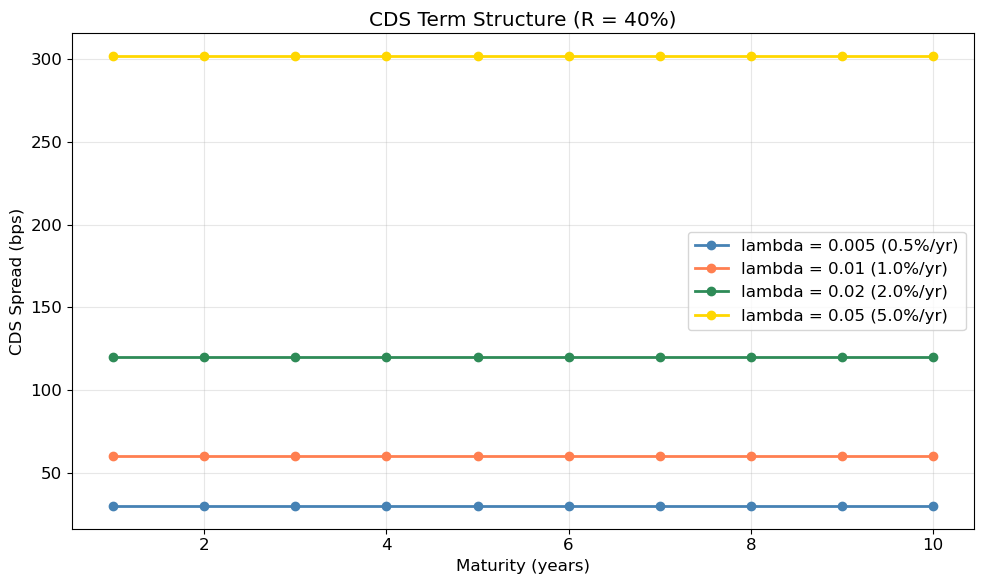

In [11]:
# CDS term structure for different credit qualities
maturities = np.arange(1, 11)
hazard_rates = [0.005, 0.01, 0.02, 0.05]

fig, ax = plt.subplots()
for lam, c in zip(hazard_rates, colors):
    spreads = [cds_spread(lam, 0.40, 0.03, m, 4) * 10000 for m in maturities]
    ax.plot(maturities, spreads, 'o-', color=c, linewidth=2, label=f'lambda = {lam} ({lam*100:.1f}%/yr)')

ax.set_xlabel('Maturity (years)')
ax.set_ylabel('CDS Spread (bps)')
ax.set_title('CDS Term Structure (R = 40%)')
ax.legend()
plt.tight_layout()
plt.show()

With a constant hazard rate, the CDS spread is nearly flat across maturities — it is almost entirely determined by the hazard rate and recovery rate. In practice, CDS term structures often slope upward (for investment-grade names, reflecting the increasing risk over longer horizons) or can even invert (for distressed names, where near-term default risk is highest).

### Reading CDS Markets in Practice

In practice, CDS traders and credit analysts watch several signals:

- **5-year CDS spread:** The benchmark maturity. A spread above 500 bps typically indicates severe distress.
- **CDS-bond basis:** The difference between CDS spread and bond spread for the same issuer. When positive,
  CDS protection is more expensive than the bond spread implies, often signaling hedging demand.
- **Term structure slope:** An inverted CDS curve (short-term > long-term) signals imminent default risk.
- **CDS spread changes:** A rapid widening (e.g., 50 bps in a week) is often a leading indicator of
  rating downgrades or financial distress.

During the 2008 financial crisis, CDS spreads on Lehman Brothers widened from 100 bps to over 700 bps
in the months before its bankruptcy. Those who watched the CDS market had early warning.

---
## 11. Credit Spread Decomposition

### What Makes Up a Credit Spread?

When a corporate bond yields 5.5% and the risk-free Treasury yields 4.0%, the 150 bps difference is the **credit spread**. But what exactly is the investor being compensated for?

The credit spread can be decomposed into three components:

$$s \approx \underbrace{\lambda (1-R)}_{\text{Expected loss}} + \underbrace{\text{Risk premium}}_{\text{Compensation for bearing default risk}} + \underbrace{\text{Liquidity premium}}_{\text{Cost of illiquidity}}$$

**1. Expected loss component:** The compensation for the statistically expected loss from defaults. For a safe AAA bond, this is tiny.

**2. Credit risk premium:** The extra return investors demand *beyond* expected losses for bearing the uncertainty of credit risk. Think of it as compensation for the possibility that losses could be worse than expected.

**3. Liquidity premium:** Corporate bonds trade less frequently than Treasuries. Investors demand extra yield for the risk that they might not be able to sell quickly at a fair price.

> **Key Concept:** Research consistently shows that expected losses explain only a fraction of credit spreads, especially for investment-grade bonds. The bulk of the spread is risk premium and liquidity premium. This is known as the "credit spread puzzle."

> **CFA Exam Tip:** Understanding spread decomposition is crucial for portfolio management. If you believe liquidity premiums are too high, you might overweight corporate bonds to earn excess returns.

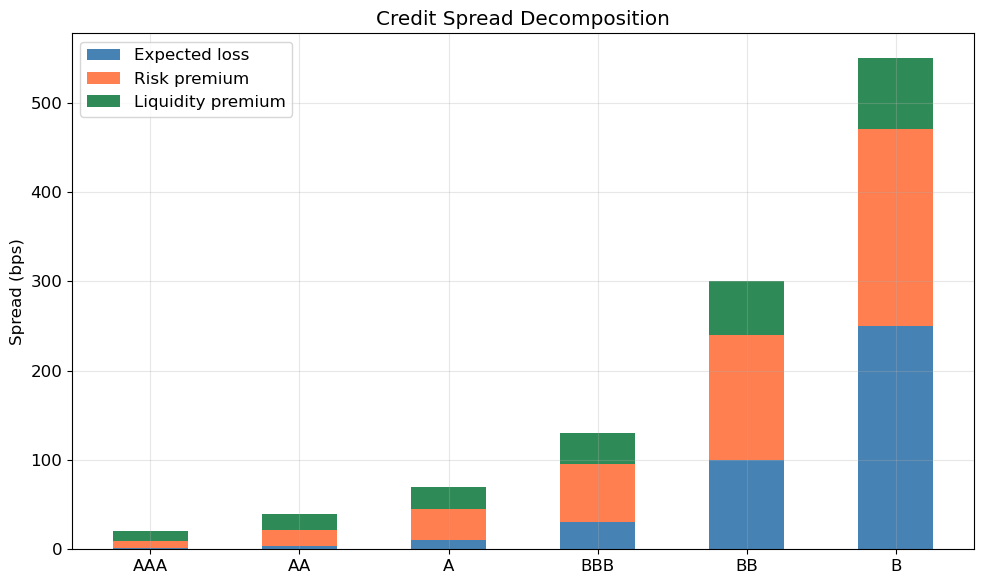

In [12]:
# Decomposition illustration
ratings_plot = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B']
# Stylised spreads in bps
total_spread = np.array([20, 40, 70, 130, 300, 550])
expected_loss = np.array([1, 4, 10, 30, 100, 250])
risk_premium = np.array([8, 18, 35, 65, 140, 220])
liquidity = total_spread - expected_loss - risk_premium

fig, ax = plt.subplots()
x = np.arange(len(ratings_plot))
w = 0.5
ax.bar(x, expected_loss, w, label='Expected loss', color=PRIMARY)
ax.bar(x, risk_premium, w, bottom=expected_loss, label='Risk premium', color=SECONDARY)
ax.bar(x, liquidity, w, bottom=expected_loss + risk_premium, label='Liquidity premium', color=TERTIARY)
ax.set_xticks(x)
ax.set_xticklabels(ratings_plot)
ax.set_ylabel('Spread (bps)')
ax.set_title('Credit Spread Decomposition')
ax.legend()
plt.tight_layout()
plt.show()

The stacked bar chart reveals several interesting patterns:

- For **investment-grade bonds** (AAA through BBB), expected losses are a very small fraction of total spreads. Most of the spread is risk premium and liquidity premium — investors are being generously compensated beyond the actuarial loss.
- For **high-yield bonds** (BB, B), expected losses become a much larger share of the total spread, which makes sense given the much higher default rates.
- **Liquidity premium** is relatively stable across ratings (in our stylised example), reflecting the general illiquidity of corporate bonds vs. Treasuries.

This decomposition explains why many active bond managers focus on investment-grade corporates — the spread compensation tends to more than cover the actual default losses.

---
## 12. References

1. Merton, R. C. "On the Pricing of Corporate Debt," *Journal of Finance*, 1974.
2. Duffie, D. & Singleton, K. *Credit Risk*, Princeton University Press, 2003.
3. Lando, D. *Credit Risk Modeling*, Princeton University Press, 2004.
4. Hull, J. C. *Options, Futures, and Other Derivatives*, 11th ed., Pearson, 2022.
5. Schonbucher, P. *Credit Derivatives Pricing Models*, Wiley, 2003.
6. CFA Institute, *CFA Program Curriculum Level I — Fixed Income*.